In [38]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from skmap.misc import find_files, GoogleSheet, ttprint
import warnings
import multiprocess as mp
import time
from scipy.special import expit, logit
import warnings
from sklearn.metrics import d2_tweedie_score
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, cross_val_score, HalvingGridSearchCV, KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
import joblib
import pickle
from sklearn.metrics import r2_score, mean_squared_error, make_scorer#, root_mean_squared_error
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
# from cubist import Cubist
from sklearn.base import BaseEstimator, TransformerMixin
from pathlib import Path
from trees_rf import TreesRandomForestRegressor
from model_fit import read_features, cfi_calc, parameter_fine_tuning, calc_ccc, separate_data, rscfi 
from model_fit import accuracy_plot, plot_top_features, pdp_hexbin, plot_histogram, calc_metrics, accuracy_strata_plot, accuracy_plot_pred_space, calc_metrics_modified
import warnings
from sklearn.inspection import permutation_importance
warnings.filterwarnings('ignore')
import os
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import json
from datetime import datetime
import os
import numpy as np
import matplotlib.pyplot as plt
from cmcrameri import cm
import math
from matplotlib.ticker import FuncFormatter  # Added

cmap = cm.batlow_r  
cmap.set_bad(color="#F8F8FF")


folder_path = '/mnt/ripley/global_soc/scikit-map/global-soil-mapping'
# prop_list = ['ocd', 'soc', 'bulk.density', 'ph.h2o' ,'coarse']
prop_list = ['ocd', 'soc', 'bulk.density', 'ph.h2o']

transforms_dict = {
    'ocd': 'log1p',
    'soc': 'log1p',
    'bulk.density': None,
    'ph.h2o': None,
    'coarse': 'log1p'
}
version = '20250204'


In [39]:
model_list

['/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ph.h2o/model_rf.ph.h2o_ccc_v20250204.joblib']


ocd--------------------------------------------------------------


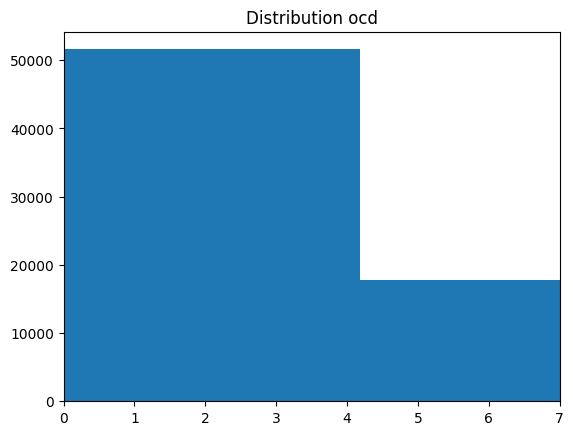

More then one model present, check the list! Using only the first one
['/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ocd/model_rf.ocd_ccc_v20250204.joblib', '/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ocd/model_rf.ocd_ccc_v20250204_clean.joblib']

soc--------------------------------------------------------------


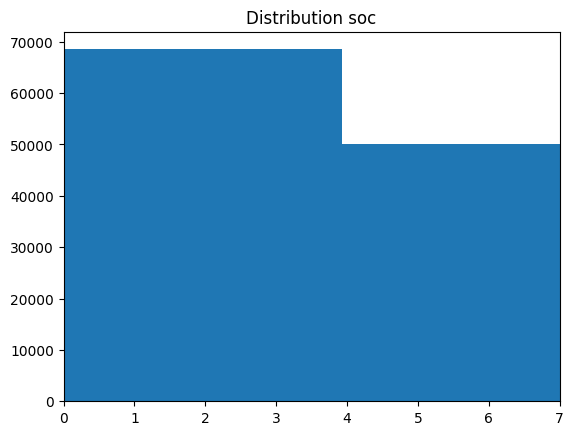

More then one model present, check the list! Using only the first one
['/mnt/ripley/global_soc/scikit-map/global-soil-mapping/soc/model_rf.soc_ccc_v20250204.joblib', '/mnt/ripley/global_soc/scikit-map/global-soil-mapping/soc/model_rf.soc_ccc_v20250204_clean.joblib']

bulk.density--------------------------------------------------------------


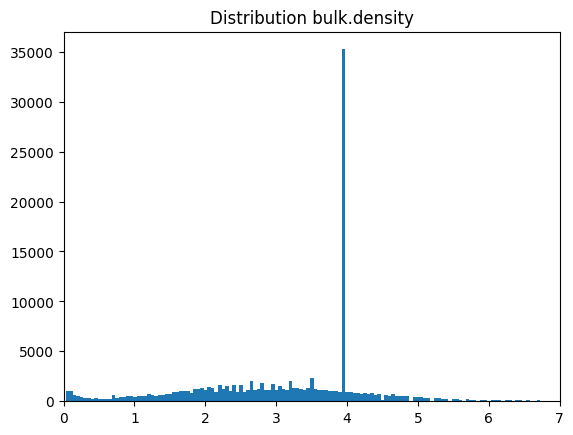


ph.h2o--------------------------------------------------------------


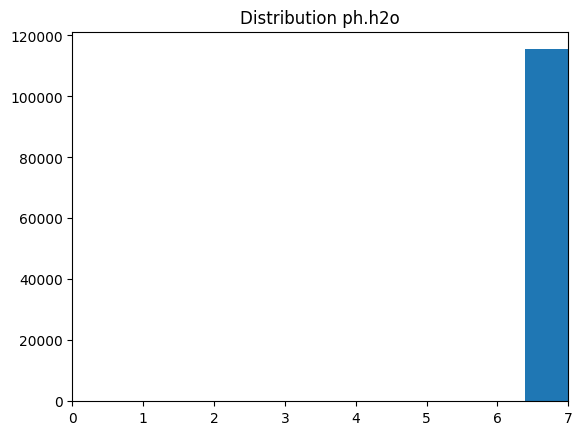

More then one model present, check the list! Using only the first one
['/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ph.h2o/model_rf.ph.h2o_ccc_v20250204.joblib', '/mnt/ripley/global_soc/scikit-map/global-soil-mapping/ph.h2o/model_rf.ph.h2o_ccc_v20250204_clean.joblib']


In [41]:
# general accuracy

results_cv = []

for prop in prop_list:
    print(f'\n{prop}--------------------------------------------------------------')
    space = transforms_dict[prop]
    output_folder = folder_path+'/'+prop
    os.makedirs(output_folder, exist_ok=True)
    
    if space=='log1p':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_log1p'
    elif space=='boxcox':
        # df.loc[:,f'{prop}_log1p'] = np.log1p(df[prop])
        tgt = f'{prop}_boxcox'
        cal[f'{prop}_boxcox'], fitted_lambda = boxcox(cal['ocd'], lmbda=None)
    else:
        tgt = prop
    
    # read in data--------------------------------------------------------------
    train_full = pd.read_csv(f'{output_folder}/prediction_cv_v{version}.csv')
    test_full = pd.read_csv(f'{output_folder}/prediction_test_{prop}_v{version}.csv')
    y_ref = np.expm1(np.concatenate([train_full[tgt].to_numpy(), test_full[tgt].to_numpy()]))

    plt.hist(y_ref, bins=200)
    plt.title(f'Distribution {prop}')
    plt.xlim([0,7])
    plt.show()

        
    # accuracy plot
    model_list = find_files(folder_path+f'/{prop}',f'*model*rf*{prop}*{version}*joblib')
    model_list = [str(i) for i in model_list]
    if len(model_list) > 1:
        print("More then one model present, check the list! Using only the first one")
        print(model_list)
        model_list = [model_list[0]]
    
    for idep in ['0-30','30-60','60-100','total']:
        if idep == '0-30':
            train = train_full.loc[(train_full['hzn_dep']<=30)&(train_full['hzn_dep']>=0)]
            test = test_full.loc[(test_full['hzn_dep']<=30)&(test_full['hzn_dep']>=0)]
        elif idep == '30-60':
            train = train_full.loc[(train_full['hzn_dep']<=60)&(train_full['hzn_dep']>30)]
            test = test_full.loc[(test_full['hzn_dep']<=60)&(test_full['hzn_dep']>30)]
        elif idep == '60-100':
            train = train_full.loc[(train_full['hzn_dep']>60)&(train_full['hzn_dep']<=100)]
            test = test_full.loc[(test_full['hzn_dep']>60)&(test_full['hzn_dep']<=100)]
        elif idep == '0-100':
            train = train_full.loc[(train_full['hzn_dep']>=0)&(train_full['hzn_dep']<=100)]
            test = test_full.loc[(test_full['hzn_dep']>=0)&(test_full['hzn_dep']<=100)]
            assert train.shape[0] == train_full.shape[0], "Something is weird"
            assert test.shape[0] == test.shape[0], "Something is weird"
        elif idep == 'total':
            train = train_full.copy()
            test = test_full.copy()
        # else:
        #     train = train_full.loc[train_full['hzn_dep']>100]
        #     test = test_full.loc[test_full['hzn_dep']>100]
        
        
        for model_id in model_list:
            mdl = 'ccc'
            for test_type in ['cv.spatial', 'cv.loyo', 'test']:
                if test_type != 'test':
                    y_test = train[tgt]
                    y_pred = train[f'{tgt}_{test_type}_{mdl}']
                    clen = len(train)
                else:
                    y_test = test[tgt]
                    y_pred = test[f'{tgt}_test_{mdl}']
                    clen = len(test)
                
                # Back-transform if necessary
                if (prop == 'ocd') or (prop == 'soc'):
                    y_test_orig = np.expm1(y_test)
                    y_pred_orig = np.expm1(y_pred)
                    p = 1.5
                elif prop == 'ph.h2o' or prop == 'bulk.density':
                    y_test_orig = y_test
                    y_pred_orig = y_pred
                    p = 0
                else:
                    raise Exception(f"Method not implemented for properites {prop}")

                rmse, mae, medae, mape, R2_transformed_space, _, bias = calc_metrics_modified(y_test_orig, y_pred_orig)
                rmse_transformed_space, _, _, _, ccc, r2, _ = calc_metrics_modified(y_test, y_pred)
                mask = np.isfinite(y_test) & np.isfinite(y_pred)
                y_test = y_test[mask]
                y_pred = y_pred[mask]

                mask = (y_test_orig>0) & (y_pred_orig>0)
                y_test_orig = y_test_orig[mask]
                y_pred_orig = y_pred_orig[mask]
                d2 = d2_tweedie_score(y_test_orig, y_pred_orig, power=p)

                
                results_cv.append({
                    'prop':prop,
                    'model': mdl,
                    'depth': idep,
                    'count': clen,
                    'evaluation_type': test_type,
                    'RMSE': rmse,
                    'CCC': ccc,
                    'D2': d2,
                    'R2': r2,
                    'bias': bias,
                    'R2_transformed_space': R2_transformed_space,
                    'rmse_transformed_space': rmse_transformed_space
                })

results_cv = pd.DataFrame(results_cv)
# results_cv.to_csv(f'{folder_path}/material/metrics_all.prop.depth_{version}.csv',index=False)

In [43]:
results_cv.loc[results_cv['evaluation_type']=='test'].to_csv('metrics_props.csv')